In [18]:
import sys
import argparse

sys.argv = ['script_name', '--forward_amount', '0.5']

parser = argparse.ArgumentParser()
parser.add_argument('--forward_amount', type=float, help='前进的距离')

args = parser.parse_args()

from config import config
from env.v0d0 import Env
from quaternion import from_euler_angles, as_float_array
from utils.angles import *
import torch
import pickle
import numpy as np
import habitat_sim
from habitat.utils.visualizations import maps
import random
from draw import Draw
import time
config['random_seed'] = int(time.time())
env = Env(config)
drawer = Draw()
env.reset()

: 

In [4]:
def rotation_vector_between_vectors(v1, v2):
    # 计算旋转轴（叉积）
    axis = np.cross(v1, v2)
    # 计算旋转角度
    angle = np.arccos(np.clip(np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)), -1.0, 1.0))
    # 返回旋转向量（旋转轴方向，乘以旋转角度）
    if np.linalg.norm(axis) == 0:  # 如果两个向量平行，叉积为0，表示没有旋转
        return np.zeros(3)
    else:
        return axis / np.linalg.norm(axis) * angle

In [5]:
def change_dim_array(array):
    num1 = array[-1]
    return np.array([array[0], num1 , 0])
def change_dim_vector(vector):
    num1 = vector[-1]
    num2 = vector[-2]
    return np.array([vector[0], num1 , num2])
    

In [6]:
def Angle(agent_rotation,target_rotation):
    a = angle_between_quats(agent_rotation,target_rotation)
    return np.degrees(a)

In [15]:


stander = change_dim_array(np.array([0,env.get_source_pos()[0][-2],-1]))


In [16]:
sound_agent_vertor = change_dim_array(env.get_source_pos()[0] - env.get_agent_pos()[0])

target_rotation_vector = change_dim_vector(rotation_vector_between_vectors(sound_agent_vertor, stander))

target_rotation = quaternion.from_rotation_vector(target_rotation_vector)

agent_rotation = env.get_agent_rotation()[0]

angle = Angle(agent_rotation , target_rotation)

angle

159.18037969592848

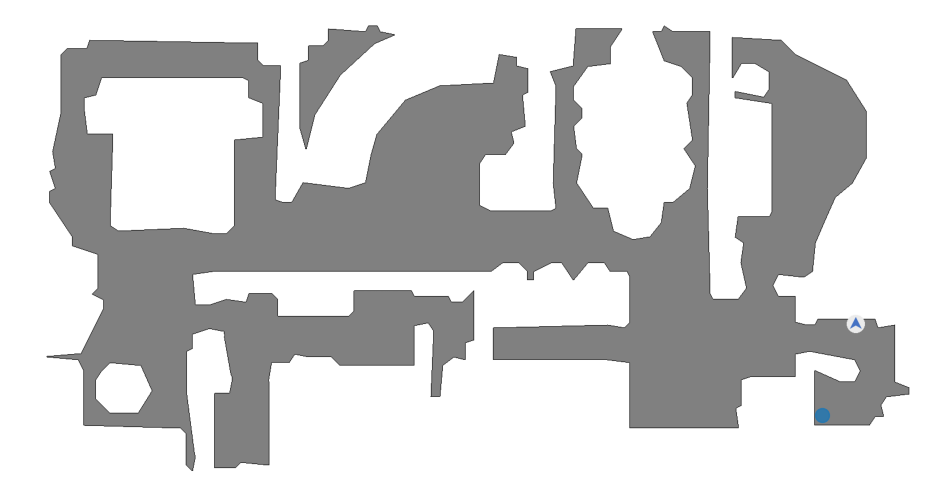

In [17]:

drawer.show_graph(env)

In [11]:
env.step([{
            "rl_pred": 1,
            "lstm_h": np.zeros((config["hid_dim_l"],), np.float32),
            "lstm_c": np.zeros((config["hid_dim_l"],), np.float32),
        }])

[19:17:01:307043]:[Sensor] AudioSensor.cpp(104)::setAudioListenerTransform : [Audio]  Setting the agent transform : position [ Vector(1.54075, 0.072447, -4.69139) ], rotQuat[ Vector(0.965926, 0, 0.258819, 0) ]
[19:17:01:307155]:[Sensor] AudioSensor.cpp(321)::createAudioSimulator : [Audio]  Create audio simulator
[19:17:01:307180]:[Sensor] AudioSensor.cpp(130)::runSimulation : [Audio]  Running the audio simulator


([{'camera': array([[[ 76,  64,  47, 255],
           [ 77,  64,  47, 255],
           [ 69,  58,  37, 255],
           ...,
           [176, 153, 121, 255],
           [171, 148, 117, 255],
           [173, 150, 119, 255]],
   
          [[ 78,  67,  49, 255],
           [ 79,  67,  50, 255],
           [ 72,  62,  40, 255],
           ...,
           [171, 148, 117, 255],
           [171, 148, 117, 255],
           [174, 151, 120, 255]],
   
          [[ 85,  73,  53, 255],
           [ 82,  69,  52, 255],
           [ 78,  67,  44, 255],
           ...,
           [172, 151, 120, 255],
           [172, 151, 120, 255],
           [175, 154, 123, 255]],
   
          ...,
   
          [[ 80,  68,  52, 255],
           [ 74,  63,  47, 255],
           [ 61,  52,  35, 255],
           ...,
           [117, 101,  78, 255],
           [117, 101,  78, 255],
           [116, 101,  80, 255]],
   
          [[ 79,  67,  51, 255],
           [ 73,  61,  43, 255],
           [ 62,  54,  36, 25